In [1]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [2]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'common_cause_fixed_interventions'
program = 'common_cause'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'pareto_fitness.txt')
files = glob(pattern, recursive=True)

records = []
for fp in files:
    df = pd.read_csv(fp, sep='\t', header=None, names=['generation', 'fitness_class'])
    df[['fitness', 'class']] = pd.DataFrame(
        df['fitness_class'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ).tolist(),
        index=df.index,
    )
    df['run'] = path.basename(path.dirname(fp))
    records.append(df[['generation', 'fitness', 'class', 'run']])
    # drop duplicate entries
    records[-1] = records[-1].drop_duplicates(subset=['generation', 'fitness', 'class', 'run'])

if records:
    pareto_fitness = pd.concat(records, ignore_index=True)
else:
    pareto_fitness = pd.DataFrame(columns=['generation', 'fitness', 'class', 'run'])

# Aggregate mean/std per generation and class and median and interquartile range
pareto_stats = (
    pareto_fitness
    .groupby(['generation', 'class'])['fitness']
    .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])
    .reset_index()
    .rename(columns={'mean': 'fitness_mean', 'std': 'fitness_std', 'count': 'n', 'median': 'fitness_median', '<lambda_0>': 'fitness_q1', '<lambda_1>': 'fitness_q3'})
)
pareto_stats['fitness_std'] = pareto_stats['fitness_std'].fillna(0)

print(f"Found {len(files)} pareto_fitness.txt files")
print(pareto_stats.head())
print(f"\nGenerations: {pareto_stats['generation'].min() if not pareto_stats.empty else 'NA'} to {pareto_stats['generation'].max() if not pareto_stats.empty else 'NA'}")

# Save aggregated stats to a new file csv named ex_name + '_pareto_stats.csv' and
# saved in ../results/synhesis
output_fp = path.join('..', 'results', 'synthesis', f'{ex_name}_pareto_stats.csv')
pareto_stats.to_csv(output_fp, index=False)

Found 10 pareto_fitness.txt files
   generation  class  fitness_mean  fitness_std   n  fitness_median  \
0           0     -1   -187.693714     0.036586  10     -187.679732   
1           1     -2   -168.268505     0.001312  10     -168.267990   
2           1     -1   -183.088987     0.012283  10     -183.086217   
3           2     -3   -131.178848     0.036342   6     -131.181364   
4           2     -2   -128.989685     0.003076   4     -128.988608   

   fitness_q1  fitness_q3  
0 -187.725499 -187.662087  
1 -168.269330 -168.267696  
2 -183.095701 -183.081143  
3 -131.209526 -131.146374  
4 -128.990572 -128.987721  

Generations: 0 to 300


/tmp/ipykernel_140209/1028103046.py:31: FutureWarning: The provided callable <function median at 0x73f4841a6020> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])


In [3]:
# print the fitness values for generation 250 and class 0 for all the 10 runs, one value for each run
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
print(f"\nFitness values for generation {gen} and class {cls}:")
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        print(f"Run {run}: {run_fitness[0]}")
    else:
        print(f"Run {run}: No data")

# print median and interquartile range for generation 250 and class 0 using 1 value for each run, so total 10 values
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
fitness_values = []
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        fitness_values.append(run_fitness[0])
if fitness_values:  
    median_fitness = np.median(fitness_values)
    q1 = np.percentile(fitness_values, 25)
    q3 = np.percentile(fitness_values, 75)
    iqr = q3 - q1
    print(f"\nMedian fitness for generation {gen} and class {cls}: {median_fitness}")
    print(f"Interquartile range (IQR) for generation {gen} and class {cls}: {iqr} (Q1: {q1}, Q3: {q3})")


Fitness values for generation 250 and class 0:
Run frandone_26_1_14_170408_797176_4370_0: -64.12067635000135
Run babbage.units.it_26_1_20_144106_39636_3060208_0: -60.19780487120285
Run babbage.units.it_26_1_20_185210_761073_3065204_0: -59.6157220770955
Run babbage.units.it_26_1_20_112447_642093_3056180_0: -73.96356385681634
Run rdoz_26_1_20_150824_943334_85163_0: -54.49246651693961
Run babbage.units.it_26_1_20_191032_424625_3065536_0: -58.41173505293516
Run frandone_26_1_19_155904_702148_6686_0: -57.71950575860818
Run babbage.units.it_26_1_20_161038_102281_3062071_0: -52.39038853930843
Run rdoz_26_1_20_122538_263560_67733_0: -64.07668077762163
Run babbage.units.it_26_1_20_163556_829341_3062773_0: -57.90793103576729

Median fitness for generation 250 and class 0: -59.01372856501533
Interquartile range (IQR) for generation 250 and class 0: 5.340349723118976 (Q1: -63.106961801016936, Q3: -57.76661207789796)


In [4]:
# print row of pareto_stats for generation 250 and class 0
gen = 250
cls = 0
gen_cls_stats = pareto_stats[(pareto_stats['generation'] == gen) & (pareto_stats['class'] == cls)]
print(f"\nAggregated stats for generation {gen} and class {cls}:")
print(gen_cls_stats)


Aggregated stats for generation 250 and class 0:
     generation  class  fitness_mean  fitness_std   n  fitness_median  \
996         250      0    -60.289647     6.039383  10      -59.013729   

     fitness_q1  fitness_q3  
996  -63.106962  -57.766612  


In [5]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood += interventional_likelihood
    likelihood_base += interventional_likelihood_base


print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Total likelihood of real program: -34.49340885465722
Total likelihood of baseline program: -57.44357480040555


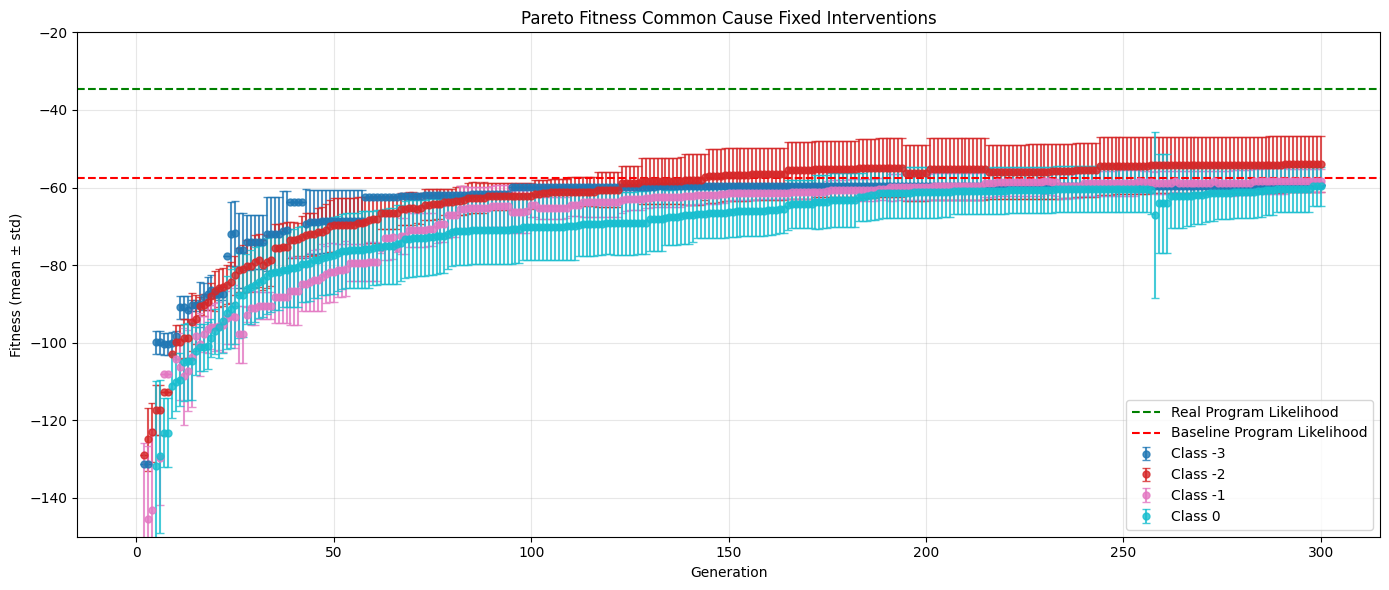

In [6]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_mean'],
            yerr=cls_df['fitness_std'],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-150, -20])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

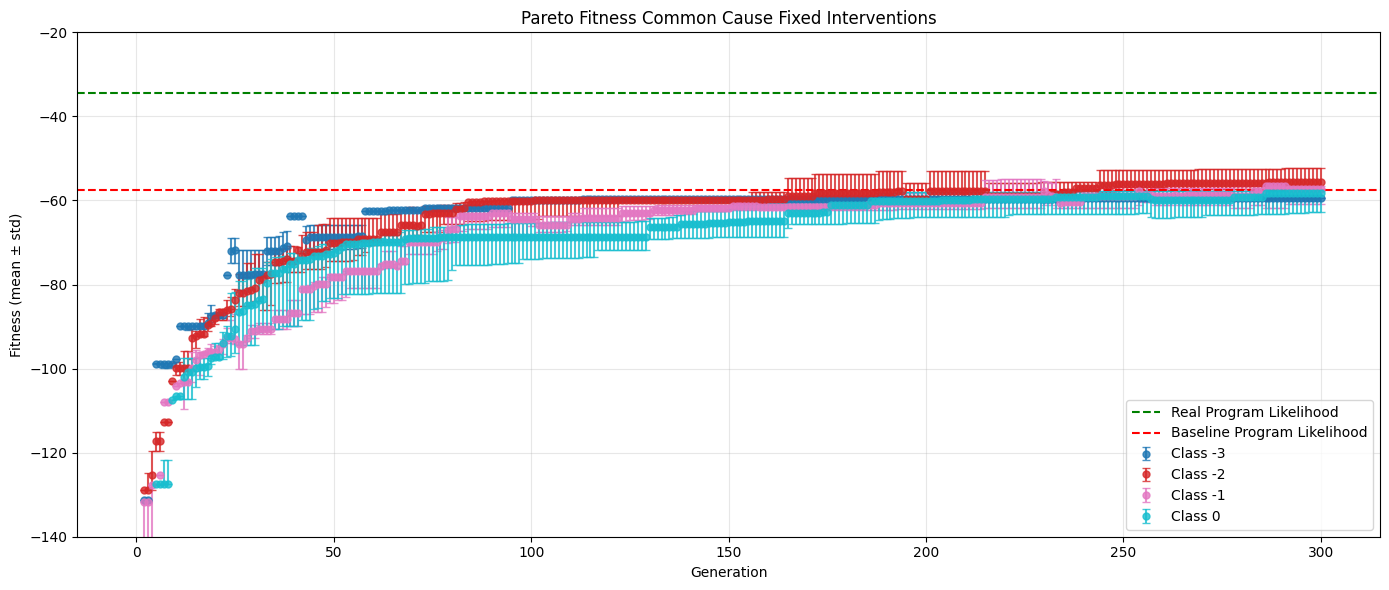

In [13]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_median'],
            yerr= [cls_df['fitness_median'] - cls_df['fitness_q1'], cls_df['fitness_q3'] - cls_df['fitness_median']],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-140, -20])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# using pareto_stats, for each class, generate a file txt with columns: generation, median_fitness, fitness_25perc, fitness_75perc
# separated by spaces, named 'class_' + class + '_fitness_summary'+ '.txt' and saved in ../results/synthesis/program
# with column headers: generation median_fitness fitness_25perc fitness_75perc

for cls in classes:
    cls_df = pareto_stats[pareto_stats['class'] == cls]
    output_fp = path.join('..', 'results', 'synthesis', program, f'class_{cls}_fitness_summary.txt')
    cls_df[['generation', 'fitness_median', 'fitness_q1', 'fitness_q3']].to_csv(
        output_fp,
        sep=' ',
        index=False,
        header=['generation', 'median_fitness', 'fitness_25perc', 'fitness_75perc']
    )



In [9]:
# find the folder that contains the best fitnes and in that folder open the folder first_front which contains files like 0.txt, 1.txt... and find the file
# that contains in the last row [best fitness, n] the best fitness and print the content of that file
# ...existing code...
# find the run folder that contains the best fitness, open its first_front/*.txt files,
# check the last non-empty row for [best_fitness, n] and print the matching file content
import math
from glob import glob

if pareto_fitness.empty:
    print("No pareto_fitness data available.")
else:
    best_idx = pareto_fitness['fitness'].idxmax()
    best_fitness = float(pareto_fitness.loc[best_idx, 'fitness'])
    best_runs = pareto_fitness[pareto_fitness['fitness'] == best_fitness]['run'].unique().tolist()
    print(f"Best fitness = {best_fitness}, candidate runs: {best_runs}")

    found = False
    for run in best_runs:
        run_dir = path.join(base_dir, run)
        ff_dirs = glob(path.join(run_dir, "**", "first_front"), recursive=True)
        for ff in ff_dirs:
            txt_files = sorted(glob(path.join(ff, "*.txt")))
            for txt_path in txt_files:
                with open(txt_path, "r") as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 1:
                    try:
                        val = float(last_row[0])
                    except Exception:
                        continue
                    if math.isclose(val, best_fitness, rel_tol=1e-9, abs_tol=1e-6):
                        print(f"Found matching file: {txt_path}")
                        print("---- file content ----")
                        print("\n".join(lines))
                        print("----------------------")
                        found = True
                        # Save the matching file content to a new file in ../results/synthesis
                        output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front.txt')
                        with open(output_file, 'w') as out_f:
                            out_f.write("\n".join(lines))
                        break
            if found:
                break
        if found:
            break

    if not found:
        print("No first_front/*.txt file found whose last row matches the best fitness.")
# ...existing code...

Best fitness = -43.88582526670157, candidate runs: ['babbage.units.it_26_1_20_163556_829341_3062773_0']
Found matching file: ../results/common_cause_fixed_interventions/babbage.units.it_26_1_20_163556_829341_3062773_0/first_front/10.txt
---- file content ----
Generation:
300
Phenotype:
3
V1 = gm([0, 7, 3], [0, 4, 3]);
V2 = V1;
V2 = V2 + gm([0, 7, 3], [0, 4, 3]);
V3 = V2;
V3 = V3 + gm([0, 7, 3], [0, 4, 3]);
Pre-processed Program
:C = gm([1.000000, 1.000000], [7, 4], [3, 3]);F = C;F = F;F = F + gm([1.000000, 1.000000], [7, 4], [3, 3]);T = F;T = T;T = T + gm([1.000000, 1.000000], [7, 4], [3, 3]);Genotype:
[382, 254, 179, 132, 233, 78, 352, 403, 246, 51, 0, 313, 96, 462, 8, 298, 153, 460, 412, 62, 411, 368, 180]
Tree:
None
Fitness on 5000 data:
-43.865058617399626
Fitness:
[-43.88582526670157, -2]
----------------------


In [10]:
# find the best file per complexity (n) in the last evolution step across all runs
import os
import re
import ast
from glob import glob

def _extract_gen_num(p: str):
    parts = p.split(os.sep)
    for part in reversed(parts):
        m = re.search(r'(?:gen|generation)[_-]?(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
        m = re.fullmatch(r'g(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
    return None

def _coerce_num(val):
    try:
        num = float(val)
    except Exception:
        return None
    if abs(num - round(num)) < 1e-9:
        return int(round(num))
    return num

if pareto_fitness.empty:
    print('No pareto_fitness data available.')
else:
    max_gen = pareto_fitness['generation'].max()
    if max_gen is not None:
        max_gen = int(max_gen)

    ff_dirs = glob(path.join(base_dir, '**', 'first_front'), recursive=True)
    if not ff_dirs:
        print('No first_front directory found under base_dir.')
    else:
        if max_gen is not None:
            filtered = [d for d in ff_dirs if _extract_gen_num(d) == max_gen]
        else:
            filtered = []
        if filtered:
            ff_dirs = filtered

        best_by_n = {}
        for ff_dir in ff_dirs:
            txt_files = sorted(glob(path.join(ff_dir, '*.txt')))
            for txt_path in txt_files:
                with open(txt_path, 'r') as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 2:
                    fitness = _coerce_num(last_row[0])
                    n_val = _coerce_num(last_row[1])
                    if fitness is None or n_val is None:
                        continue
                    current = best_by_n.get(n_val)
                    if current is None or fitness > current['fitness']:
                        best_by_n[n_val] = {
                            'fitness': fitness,
                            'path': txt_path,
                            'lines': lines,
                        }

        if not best_by_n:
            print('No valid first_front/*.txt files found for the last evolution step.')
        else:
            for n_val in sorted(best_by_n.keys()):
                entry = best_by_n[n_val]
                print(f'Best for n={n_val} (fitness={entry["fitness"]}): {entry["path"]}')
                print('---- file content ----')
                print('\n'.join(entry['lines']))
                print('----------------------')

                output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front_n_{n_val}.txt')
                with open(output_file, 'w') as out_f:
                    out_f.write('\n'.join(entry['lines']))


Best for n=-3 (fitness=-59.38247200278482): ../results/common_cause_fixed_interventions/rdoz_26_1_20_122538_263560_67733_0/first_front/7.txt
---- file content ----
Generation:
300
Phenotype:
3
V1 = gm([50, 5.4, 3.2], [1, 8, 3]);
if V1 < 10 {
V2 = V1;
} else {
V2 = V1 + 15.6 - V1 - 41.5;
} end if;
V2 = V2 + gm([50, 5.4, 3.2], [1, 8, 3]);
if V1 < 10 {
V3 = V2;
} else {
V3 = V2 + 15.6 - V2 - 41.5;
} end if;
V3 = V3 + gm([50, 5.4, 3.2], [1, 8, 3]);
Pre-processed Program
:C = gm([0.980392, 0.019608], [5.4, 8], [3.2, 3]);if C < 10 {   F = C; } else {   F = C;   F = F + 15.6;   F = F - C;   F = F - 41.5; } end if;F = F;F = F + gm([0.980392, 0.019608], [5.4, 8], [3.2, 3]);if C < 10 {   T = F; } else {   T = F;   T = T + 15.6;   T = T - F;   T = T - 41.5; } end if;T = T;T = T + gm([0.980392, 0.019608], [5.4, 8], [3.2, 3]);Genotype:
[259, 194, 85, 118, 467, 234, 497, 305, 288, 254, 439, 464, 12, 195, 156, 370, 56, 184, 1, 32, 365, 66, 360, 165, 326, 38, 60, 144, 367, 106, 292, 442, 396, 149, 218